# 03. Models

Three models on the same folds: a logistic regression as the white box, XGBoost as the machine
learning model, and TabPFN as the tabular foundation model. TabPFN runs on a GPU in Colab, so it has
its own notebook (`03b_tabpfn_colab.ipynb`) and comes back as a file.

All three predict **the two decisions separately and multiply them**, rather than predicting the match
directly. Section 4 shows the direct approach and section 5 shows why we moved away from it.

The point of this notebook is not the scores, it is the **out-of-fold predictions**: every pair gets
a prediction from a model that never saw it during training. Notebooks 04 to 06 read those
predictions instead of refitting anything, so interpretability, stability and fairness can be worked
on in parallel. In `oof_predictions.csv`, `logit` and `xgboost` are the two-stage models we keep;
`logit_direct` and `xgboost_direct` are the baseline kept for comparison.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
from pathlib import Path

if not Path("data").is_dir():
    os.chdir("..")   # works whether Jupyter started at the repo root or inside notebooks/

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

table = pd.read_csv("data/processed/model_table.csv")

CATEGORICAL = ["her_field", "her_race", "her_goal", "his_field", "his_race", "his_goal"]
TARGETS = ["pair", "wave", "match", "fold", "her_dec", "his_dec"]
X = table.drop(columns=TARGETS)
y = table.match
groups = table.wave

print(X.shape[1], "columns,", len(X), "pairs,", round(y.mean(), 3), "positive")

60 columns, 4184 pairs, 0.165 positive


## 1. The folds

Notebook 02 already assigned every pair to a fold and stored it in the table, so every model here is
scored on the same split, and so is TabPFN, which reads the same file in Colab.

In [2]:
cv = StratifiedGroupKFold(5, shuffle=True, random_state=0)   # the one 02 used, kept for reference

table.groupby("fold").agg(pairs=("match", "size"), matches=("match", "sum"),
                          rate=("match", "mean"), waves=("wave", "nunique")).round(3)

,pairs,matches,rate,waves
fold,,,,
0,847,137,0.162,4
1,877,140,0.160,4
2,827,122,0.148,4
3,823,133,0.162,5
4,810,158,0.195,4


## 2. The white box: logistic regression

The brief asks for a white-box model and the obvious one is a logistic regression: one coefficient
per feature, readable signs, and a prediction any analyst can reproduce by hand.

The only real choice is the penalty. All of them score the same here, so we pick on sparsity rather
than on decimals.

In [3]:
def encoded(final_step):
    """One-hot the six category codes on the training fold only, then impute, scale, and fit."""
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), CATEGORICAL)],
        remainder="passthrough")
    return make_pipeline(encode, SimpleImputer(strategy="median"), StandardScaler(), final_step)

penalties = {
    "ridge (L2), C=1":   LogisticRegression(max_iter=3000, C=1),
    "lasso (L1), C=0.1":  LogisticRegression(max_iter=3000, C=0.1, l1_ratio=1, solver="liblinear"),
    "lasso (L1), C=0.05": LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1, solver="liblinear"),
}

rows = []
for name, est in penalties.items():
    pipe = encoded(est)
    auc = cross_val_score(pipe, X, y, cv=cv, groups=groups, scoring="roc_auc")
    pipe.fit(X, y)
    rows.append({"penalty": name, "ROC-AUC": round(auc.mean(), 3),
                 "features kept": int((pipe[-1].coef_ != 0).sum())})

pd.DataFrame(rows).set_index("penalty")

,ROC-AUC,features kept
penalty,,
"ridge (L2), C=1",0.581,99
"lasso (L1), C=0.1",0.579,59
"lasso (L1), C=0.05",0.579,46


The lasso at `C=0.05` drops half the features for three thousandths of AUC, which is well inside the
fold-to-fold noise. Half as many coefficients to put in front of the client is worth far more than
that, so this is our white box.

46 features kept out of 99


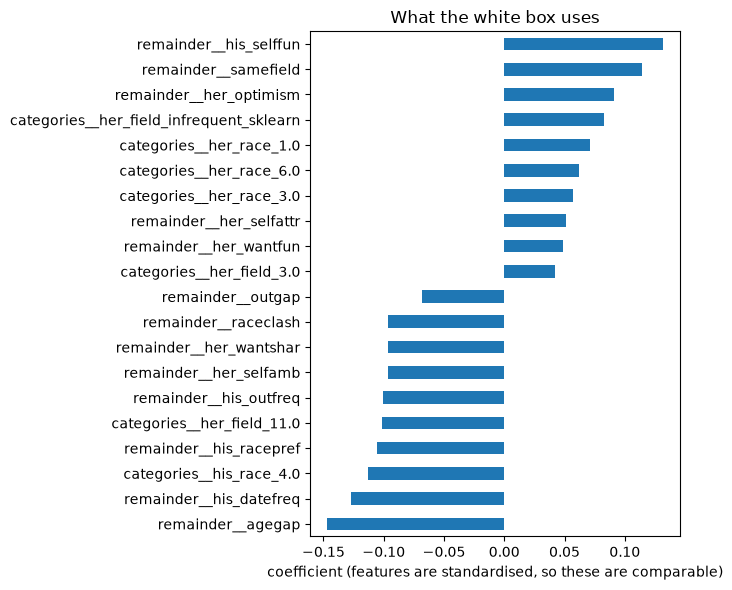

In [4]:
white_box = encoded(LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1, solver="liblinear"))
white_box.fit(X, y)

names = white_box[0].get_feature_names_out()
coefs = pd.Series(white_box[-1].coef_.ravel(), index=names)
coefs = coefs[coefs != 0].sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
pd.concat([coefs.head(10), coefs.tail(10)]).plot.barh(ax=ax)
ax.set_xlabel("coefficient (features are standardised, so these are comparable)")
ax.set_title("What the white box uses")
plt.tight_layout()

print(len(coefs), "features kept out of", len(names))

## 3. XGBoost

Same pipeline, without the scaling it does not need. The settings are deliberately modest: 4,184 rows
with a 16.5% positive rate is not much, and a deeper model only memorises the training waves.

In [5]:
def boosted():
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), CATEGORICAL)],
        remainder="passthrough")
    return make_pipeline(encode, SimpleImputer(strategy="median"),
                         XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                       subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
                                       random_state=0))

## 4. The obvious approach, and its baseline

The straightforward thing is to fit on the pairs and predict `match`. One pass over the folds: each
model is fitted on four and predicts the fifth, so every pair gets a prediction from a model that
never saw it. This is our reference point.

In [6]:
DIRECT = {"logit_direct": lambda: encoded(LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1,
                                                             solver="liblinear")),
          "xgboost_direct": boosted}

oof = table[["pair", "wave", "fold", "match"]].copy()

for k in sorted(table.fold.unique()):
    train, test = table.fold != k, table.fold == k
    for name, build in DIRECT.items():
        model = build().fit(X[train], y[train])
        oof.loc[test, name] = model.predict_proba(X[test])[:, 1]

print("predictions missing:", oof[list(DIRECT)].isna().sum().sum())
oof.head(3)

predictions missing: 0


,pair,wave,fold,match,logit_direct,xgboost_direct
0,"(1, 11)",1,1,0,0.106454,0.045065
1,"(1, 12)",1,1,0,0.362232,0.211066
2,"(1, 13)",1,1,1,0.172200,0.103035


In [7]:
print("columns:", list(oof.columns))

columns: ['pair', 'wave', 'fold', 'match', 'logit_direct', 'xgboost_direct']


## 5. What we actually use: a match is two decisions

Predicting `match` directly asks the model to hit a rare joint event: 16.5% of pairs. But a match is
just she says yes **and** he says yes, and those two decisions are far more common on their own: 37%
for her, 47% for him. So instead of one model on 4,184 pairs, we fit one model on 8,368 decisions and
multiply the two probabilities.

Twice the rows, a target that is nearly balanced, and the asymmetry between the two sides handled by
a `female` column. `dec` is unusable as a feature, since it is the answer, but it is perfectly legitimate
as a target.

In [8]:
# One row per decision: whoever is deciding becomes `self_`, their partner `other_`.
def decision_view(tab, decider):
    mine, theirs = ("her", "his") if decider == "her" else ("his", "her")
    view = tab.drop(columns=TARGETS).rename(
        columns=lambda c: c.replace(f"{mine}_", "self_").replace(f"{theirs}_", "other_"))
    view["agediff"] = view.self_age - view.other_age   # directional: follows whoever is deciding
    view["female"] = int(decider == "her")
    return view

SIDE_CATEGORICAL = ["self_field", "self_race", "self_goal", "other_field", "other_race", "other_goal"]

hers, his = decision_view(table, "her"), decision_view(table, "his")
print(hers.shape, "rows per side ->", 2 * len(hers), "decisions in total")

(4184, 61) rows per side -> 8368 decisions in total


In [9]:
def two_stage(final_step, scale):
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), SIDE_CATEGORICAL)],
        remainder="passthrough")
    steps = [encode, SimpleImputer(strategy="median")]
    if scale:
        steps.append(StandardScaler())
    return make_pipeline(*steps, final_step)

MODELS = {
    "logit": lambda: two_stage(LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1,
                                                  solver="liblinear"), scale=True),
    "xgboost": lambda: two_stage(XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                               subsample=0.8, colsample_bytree=0.8,
                                               eval_metric="logloss", random_state=0), scale=False),
}

for name, build in MODELS.items():
    oof[name] = np.nan
    for k in sorted(table.fold.unique()):
        train, test = table.fold != k, table.fold == k
        model = build().fit(pd.concat([hers[train], his[train]]),
                            pd.concat([table.her_dec[train], table.his_dec[train]]))
        oof.loc[test, name] = (model.predict_proba(hers[test])[:, 1]
                               * model.predict_proba(his[test])[:, 1])

print("predictions missing:", oof[list(MODELS)].isna().sum().sum())

predictions missing: 0


## 6. Where we stand

ROC-AUC says how well the pairs are ranked overall. PR-AUC is the one to watch here, because only
16.5% of pairs match and a model can look respectable on ROC-AUC while being useless at the top of
the ranking, which is the only part the app would ever show.

In [10]:
def score(column):
    per_fold = [roc_auc_score(g.match, g[column]) for _, g in oof.groupby("fold")]
    return {"ROC-AUC": round(roc_auc_score(oof.match, oof[column]), 3),
            "PR-AUC": round(average_precision_score(oof.match, oof[column]), 3),
            "worst fold": round(min(per_fold), 3),
            "best fold": round(max(per_fold), 3)}

ALL = list(MODELS) + list(DIRECT)   # the two-stage models first, the baseline after

results = pd.DataFrame({name: score(name) for name in ALL}).T
results.index.name = "model"
results

,ROC-AUC,PR-AUC,worst fold,best fold
model,,,,
logit,0.587,0.228,0.552,0.618
xgboost,0.585,0.218,0.553,0.612
logit_direct,0.573,0.203,0.532,0.635
xgboost_direct,0.589,0.212,0.568,0.635


In [11]:
# What the client would actually see: if the app shows the top 10% of pairs, how many are matches?
base = oof.match.mean()
rows = []
for name in ALL:
    top = oof.nlargest(int(0.10 * len(oof)), name)
    rows.append({"model": name, "match rate in the top 10%": round(top.match.mean(), 3),
                 "lift over showing pairs at random": round(top.match.mean() / base, 2)})

pd.DataFrame(rows).set_index("model")

,match rate in the top 10%,lift over showing pairs at random
model,,
logit,0.299,1.81
xgboost,0.285,1.73
logit_direct,0.237,1.44
xgboost_direct,0.230,1.39


This is the table that decides the approach. Splitting the match into two decisions costs nothing on
ROC-AUC and gains a third on the metric that matters: 29.9% of the top decile match, against 23.0%
predicting the match directly, on a base rate of 16.5%.

It also says something the slides should not bury: **ROC-AUC ranks the models in almost the reverse
order of the metric the client cares about.** Direct XGBoost has the best ROC-AUC and the worst top
decile. If the app shows a short list, the two-stage logistic regression is the best model we have,
and it is also the one we can explain coefficient by coefficient.

### How much of that is real?

Every number above comes from 4,184 pairs, and the top decile is measured on 418 of them. Before
reading anything into a gap of two points, we need to know how wide the error bars are.

In [12]:
rng = np.random.default_rng(0)

rows = []
for name in ALL:
    draws = []
    for _ in range(2000):
        sample = oof.iloc[rng.integers(0, len(oof), len(oof))]
        draws.append(sample.match[sample[name] >= sample[name].quantile(0.9)].mean())
    low, high = np.percentile(draws, [2.5, 97.5])
    rows.append({"model": name, "top 10%": round(np.mean(draws), 3),
                 "95% interval": f"[{low:.3f}, {high:.3f}]", "width": round(high - low, 3)})

pd.DataFrame(rows).set_index("model")

,top 10%,95% interval,width
model,,,
logit,0.296,"[0.250, 0.340]",0.090
xgboost,0.284,"[0.241, 0.327]",0.086
logit_direct,0.232,"[0.193, 0.274]",0.082
xgboost_direct,0.229,"[0.191, 0.269]",0.078


The interval is about eight points wide. Two consequences, and both belong in the slides.

**The two-stage gain is real.** Roughly 0.30 against 0.23, on intervals that barely meet. Splitting
the match into two decisions is not a lucky draw.

**The gap between the two-stage models is not.** 0.296 against 0.284 with intervals that overlap
almost completely: on this data the logistic regression and XGBoost are indistinguishable. We chased
this further, with eighteen more engineered features, attribute-by-attribute preference fits, directional
versions of `raceclash` and income gaps, and every variant landed inside the same interval, helping one
model while hurting the other. That is the shape of noise, so we stopped.

Which settles what the recommendation has to rest on. Performance cannot separate these models, so
interpretability, stability and fairness will.

In [13]:
oof.to_csv("data/processed/oof_predictions.csv", index=False)
print("saved", oof.shape, "to data/processed/oof_predictions.csv")

saved (4184, 8) to data/processed/oof_predictions.csv


## 7. TabPFN

TabPFN needs a GPU to be practical, so it runs in `03b_tabpfn_colab.ipynb` on Colab. It uses the same
two-stage formulation as the models above, so the three are directly comparable. The recipe:

1. open `03b` in Colab and switch the runtime to a GPU;
2. upload `data/processed/model_table.csv` when it asks;
3. it fits TabPFN on the same five folds and offers `tabpfn_oof.csv` for download;
4. drop that file in `data/processed/` and run the cell below to merge it in.

The fold column travels with the data, so TabPFN is scored on exactly the same split, with the same
two-stage target, as the two models above.

In [14]:
from pathlib import Path

tabpfn_file = Path("data/processed/tabpfn_oof.csv")
if tabpfn_file.exists():
    arrived = pd.read_csv(tabpfn_file).set_index("pair")
    for column in ["tabpfn", "tabpfn_direct"]:
        oof[column] = arrived[column].reindex(oof.pair).to_numpy()
    oof.to_csv("data/processed/oof_predictions.csv", index=False)
    print(pd.DataFrame({n: score(n) for n in ["logit", "xgboost", "tabpfn",
                                              "logit_direct", "xgboost_direct", "tabpfn_direct"]}).T)
else:
    print("tabpfn_oof.csv not here yet: run 03b in Colab, then re-run this cell.")

                ROC-AUC  PR-AUC  worst fold  best fold
logit             0.587   0.228       0.552      0.618
xgboost           0.585   0.218       0.553      0.612
tabpfn            0.600   0.234       0.578      0.633
logit_direct      0.573   0.203       0.532      0.635
xgboost_direct    0.589   0.212       0.568      0.635
tabpfn_direct     0.597   0.223       0.555      0.633


## What the next notebooks get

`data/processed/oof_predictions.csv`: one row per pair with `wave`, `fold`, `match` and one
probability column per model, all out-of-fold.

All four model columns are out-of-fold. `logit` and `xgboost` are the two-stage models we keep;
`logit_direct` and `xgboost_direct` are the baseline, there so the choice can be defended.

- **04, interpretability**: coefficients and odds ratios for the logit, SHAP for XGBoost. Note that
  the two-stage models explain a *decision*, not a match, which is arguably easier to present to the
  client: "why would she say yes to him".
- **05, stability**: the fold-to-fold spread, and the deliberate stress test: train on the
  large-group waves, test on the small-group ones.
- **06, fairness**: the metrics by ethnicity and for mixed against same-ethnicity pairs, then the
  experiment that matters: refit without `race` and see whether `imprace` and the income columns put
  the gap back on their own.

Still missing: the cost matrix. Without it there is no economic performance, and the brief asks for
it. What a match is worth against what a wasted recommendation costs is a decision for the team, not
something to invent here.